In [2]:
from google.colab import files
uploaded = files.upload()


Saving best_model.pth to best_model.pth


In [3]:
!pip install medmnist


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.0 MB/s eta 0:00:00


100%|██████████| 4.17M/4.17M [00:01<00:00, 3.30MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


Model loaded successfully
Test Accuracy: 0.9294871794871795


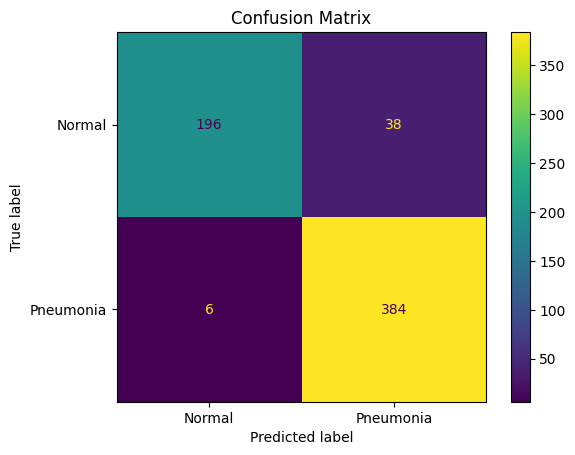


Image 1
Prediction: 1 | True: [1]

CHEST X-RAY REPORT

Findings:
Increased lung opacity patterns may be observed.
Radiographic appearance suggests inflammatory consolidation.

Impression:
Findings are consistent with pneumonia.
Clinical correlation is recommended.


Image 2
Prediction: 1 | True: [0]

CHEST X-RAY REPORT

Findings:
Increased lung opacity patterns may be observed.
Radiographic appearance suggests inflammatory consolidation.

Impression:
Findings are consistent with pneumonia.
Clinical correlation is recommended.


Image 3
Prediction: 1 | True: [1]

CHEST X-RAY REPORT

Findings:
Increased lung opacity patterns may be observed.
Radiographic appearance suggests inflammatory consolidation.

Impression:
Findings are consistent with pneumonia.
Clinical correlation is recommended.


Image 4
Prediction: 0 | True: [0]

CHEST X-RAY REPORT

Findings:
Lung fields appear clear.
No visible consolidation or abnormal opacity.

Impression:
No radiographic evidence of pneumonia.



In [4]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from medmnist import PneumoniaMNIST
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

test_dataset = PneumoniaMNIST(split='test', download=True)
test_dataset = [(transform(img), label) for img, label in test_dataset]

test_loader = DataLoader(test_dataset, batch_size=32)

model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)


model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
model.eval()

print("Model loaded successfully")


correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        labels = labels.squeeze().long()
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Test Accuracy:", correct/total)


all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        labels = labels.squeeze().long()
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Normal", "Pneumonia"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()


def generate_medical_report(prediction):

    if prediction == 1:
        return """
CHEST X-RAY REPORT

Findings:
Increased lung opacity patterns may be observed.
Radiographic appearance suggests inflammatory consolidation.

Impression:
Findings are consistent with pneumonia.
Clinical correlation is recommended.
"""
    else:
        return """
CHEST X-RAY REPORT

Findings:
Lung fields appear clear.
No visible consolidation or abnormal opacity.

Impression:
No radiographic evidence of pneumonia.
"""

# Test sur 4 images
for i in range(4):
    image, label = test_dataset[i]
    image = image.unsqueeze(0)

    with torch.no_grad():
        output = model(image)
        pred = torch.argmax(output, dim=1).item()

    print(f"\nImage {i+1}")
    print("Prediction:", pred, "| True:", label)
    print(generate_medical_report(pred))

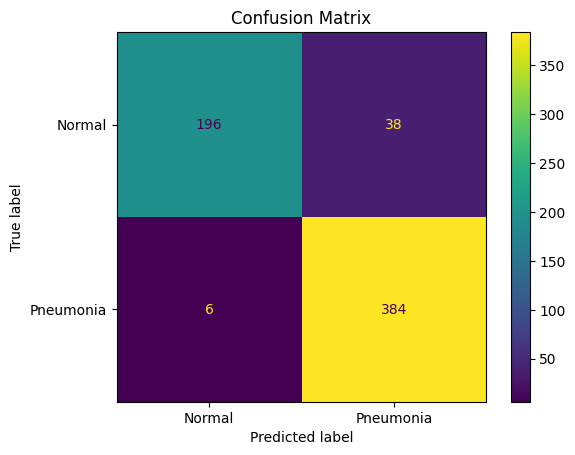

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        labels = labels.squeeze().long()
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Normal", "Pneumonia"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()
